# Fold design + stacked PCA ensemble test

Week-3 classifier-prep work on `papers_combined.parquet` (the pooled 6-use-case
dataset) — distinct from `scripts/compare_*.py`, which stay diagnostic-only per
`HANDOFF.md`. Read-only against the parquet, writes nothing back to `data/`.

In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "../../scripts")
from embedding_utils import cross_validated_roc_auc

DATA_PATH = Path("../../data/processed/papers_combined.parquet")
HOLDOUT_USE_CASE = "tech_forecasting"  # smallest (290 rows) + distinct methodological
# domain (graph/network methods) vs. the other 5. solar_leo is the interesting
# alternative to swap in — its own analyst notes flag a citation-biased seed corpus —
# but only one is held out at a time.
N_SPLITS = 5
RANDOM_STATE = 42

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df)} rows x {len(df.columns)} columns")

Loaded 2873 rows x 50 columns


## A. Target + holdout split

In [2]:
has_abstract_by_label = df.groupby("triage_label", observed=True)["has_abstract"].mean().round(3)
print("has_abstract rate by triage_label:")
print(has_abstract_by_label)
print(f"review_label non-null: {df['review_label'].notna().sum()} / {len(df)}")
print("-> pass is ~85% missing-abstract (a triage-completeness artifact, not a relevance")
print("   judgment) and review_label is 99.97% null. Target = positive/negative only;")
print("   pass and never-triaged rows are excluded from training.")

labelled = df[df["triage_label"].isin(["positive", "negative"])].copy()
labelled["y"] = (labelled["triage_label"] == "positive").astype(int)
print(f"\nLabelled subset: {len(labelled)} / {len(df)} rows")

has_abstract rate by triage_label:
triage_label
positive    0.933
negative    0.950
pass        0.153
Name: has_abstract, dtype: float64
review_label non-null: 1 / 2873
-> pass is ~85% missing-abstract (a triage-completeness artifact, not a relevance
   judgment) and review_label is 99.97% null. Target = positive/negative only;
   pass and never-triaged rows are excluded from training.

Labelled subset: 1852 / 2873 rows


In [3]:
def parse_author_count(s):
    if pd.isna(s) or s.strip() == "":
        return np.nan
    return float(len([a for a in s.split(",") if a.strip()]))

labelled["author_count"] = labelled["authors"].apply(parse_author_count)
labelled["citation_count_f"] = pd.to_numeric(labelled["citation_count"], errors="coerce").astype(float)
labelled["year_f"] = pd.to_numeric(labelled["year"], errors="coerce").astype(float)
labelled["exported_year"] = pd.to_datetime(labelled["exported_at"]).dt.year.astype(float)
labelled["paper_age"] = labelled["exported_year"] - labelled["year_f"]
labelled["citation_velocity"] = labelled["citation_count_f"] / (labelled["paper_age"] + 1)
labelled["venue_missing"] = (labelled["venue"].isna() | (labelled["venue"].str.strip() == "")).astype(float)
labelled["citation_missing"] = labelled["citation_count_f"].isna().astype(float)
labelled["author_missing"] = labelled["author_count"].isna().astype(float)
# Per-use-case percentile rank is row/group-local (no target, no cross-split
# information) -- safe to compute once on the full labelled set, unlike PCA/scaler/
# imputer below, which DO need dev-pool-only fitting (see Section C).
labelled["citation_pct_rank"] = labelled.groupby("use_case_key")["citation_count_f"].rank(pct=True)
labelled["author_pct_rank"] = labelled.groupby("use_case_key")["author_count"].rank(pct=True)

# domain_industry/domain_application/domain_technology_focus/constraints_scale/
# constraints_cost/trl_min/trl_max are dropped: established this session that they're
# either 100% redundant with use_case_key (constant per use case) or entirely empty.

dev_pool = labelled[labelled["use_case_key"] != HOLDOUT_USE_CASE].reset_index(drop=True).copy()
holdout = labelled[labelled["use_case_key"] == HOLDOUT_USE_CASE].reset_index(drop=True).copy()
print(f"Dev pool: {len(dev_pool)} rows across {dev_pool['use_case_key'].nunique()} use cases")
print(dev_pool.groupby(["use_case_key", "triage_label"], observed=True).size())
print(f"\nHoldout ({HOLDOUT_USE_CASE}): {len(holdout)} rows -- untouched until Section C's final check")
print(holdout["triage_label"].value_counts())

Dev pool: 1588 rows across 5 use cases
use_case_key     triage_label
carbon_capture   positive        147
                 negative        150
cement_binders   positive        170
                 negative         92
ner              positive        223
                 negative         89
soil_microbiome  positive         94
                 negative        263
solar_leo        positive        276
                 negative         84
dtype: int64

Holdout (tech_forecasting): 264 rows -- untouched until Section C's final check
triage_label
positive    157
negative    107
pass          0
Name: count, dtype: int64


## B. Fold design + checks

In [4]:
def first_author(s):
    if pd.isna(s) or s.strip() == "":
        return None
    return re.sub(r"\s+", " ", s.split(",")[0].strip())

dev_pool["first_author"] = dev_pool["authors"].apply(first_author)
n_no_author = dev_pool["first_author"].isna().sum()
print(f"{n_no_author} / {len(dev_pool)} rows have no parseable first author -- each gets")
print("its own singleton group (paper_id) rather than being grouped with every other")
print("missing-author row as if they were the same person.")
dev_pool["group_key"] = dev_pool["first_author"].fillna(dev_pool["paper_id"])
dev_pool["strat_key"] = dev_pool["use_case_key"] + "__" + dev_pool["triage_label"].astype(str)

print("\nSmallest (use_case, label) stratum in the dev pool:")
print(dev_pool["strat_key"].value_counts().tail(3))

23 / 1588 rows have no parseable first author -- each gets
its own singleton group (paper_id) rather than being grouped with every other
missing-author row as if they were the same person.

Smallest (use_case, label) stratum in the dev pool:
strat_key
cement_binders__negative    92
ner__negative               89
solar_leo__negative         84
Name: count, dtype: int64


In [5]:
X_idx = np.arange(len(dev_pool))
strat_key = dev_pool["strat_key"].to_numpy()
group_key = dev_pool["group_key"].to_numpy()

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(sgkf.split(X_idx, strat_key, group_key))  # materialised once, reused everywhere below

fold_assignment = np.full(len(dev_pool), -1)
for fold_i, (_, test_idx) in enumerate(FOLDS):
    fold_assignment[test_idx] = fold_i
dev_pool["fold"] = fold_assignment

print("Check 1 -- per-fold (use_case, label) breakdown:")
print(pd.crosstab([dev_pool["use_case_key"], dev_pool["triage_label"]], dev_pool["fold"]))

Check 1 -- per-fold (use_case, label) breakdown:


fold                           0   1   2   3   4
use_case_key    triage_label                    
carbon_capture  positive      30  30  29  29  29
                negative      30  30  30  30  30
cement_binders  positive      34  34  34  34  34
                negative      18  18  19  19  18
ner             positive      45  45  44  45  44
                negative      18  17  18  18  18
soil_microbiome positive      18  19  19  19  19
                negative      53  52  53  52  53
solar_leo       positive      55  56  55  55  55
                negative      16  17  17  17  17


In [6]:
print("Check 2 -- group-integrity (first-author leakage across folds):")
groups_per_fold = dev_pool.groupby("fold")["group_key"].apply(set)
violations = 0
for i in range(N_SPLITS):
    for j in range(i + 1, N_SPLITS):
        violations += len(groups_per_fold[i] & groups_per_fold[j])
print(f"Cross-fold group_key overlaps: {violations} (0 expected by construction)")

Check 2 -- group-integrity (first-author leakage across folds):


Cross-fold group_key overlaps: 0 (0 expected by construction)


In [7]:
X_dev_emb = np.stack(dev_pool["embedding"].to_numpy()).astype(float)
y_dev = dev_pool["y"].to_numpy()

print("Check 3 -- naive baseline (embedding_utils.cross_validated_roc_auc: plain")
print("StratifiedKFold, no grouping, no use_case awareness):")
naive_result = cross_validated_roc_auc(X_dev_emb, y_dev)
print(naive_result)

Check 3 -- naive baseline (embedding_utils.cross_validated_roc_auc: plain
StratifiedKFold, no grouping, no use_case awareness):


{'roc_auc': 0.6010929157987982, 'n_folds': 5}


In [8]:
def cv_roc_auc_grouped(X, y, folds):
    aucs = []
    for train_idx, test_idx in folds:
        y_test = y[test_idx]
        if len(set(y_test.tolist())) < 2:
            continue
        clf = LogisticRegression(class_weight="balanced", max_iter=1000)
        clf.fit(X[train_idx], y[train_idx])
        pos_col = list(clf.classes_).index(1)
        y_score = clf.predict_proba(X[test_idx])[:, pos_col]
        aucs.append(roc_auc_score(y_test, y_score))
    return {"roc_auc": float(np.mean(aucs)) if aucs else None, "n_folds": len(aucs)}

print("Check 4 -- StratifiedGroupKFold (use_case+label stratified, first-author grouped),")
print("same LogisticRegression config as the naive baseline:")
grouped_result = cv_roc_auc_grouped(X_dev_emb, y_dev, FOLDS)
print(grouped_result)
print(f"Delta vs. naive: {grouped_result['roc_auc'] - naive_result['roc_auc']:+.4f}")

Check 4 -- StratifiedGroupKFold (use_case+label stratified, first-author grouped),
same LogisticRegression config as the naive baseline:
{'roc_auc': 0.801751716001667, 'n_folds': 5}
Delta vs. naive: +0.2007


### Disentangling the naive-vs-grouped delta

`dev_pool` is stored in contiguous use_case blocks (confirmed below: 5 block-transitions
across 1,588 rows -- essentially zero interleaving). `cross_validated_roc_auc` uses
`StratifiedKFold(shuffle=False)`, so on block-ordered data its folds are skewed heavily
by use_case, not just "no author grouping". The naive-vs-grouped delta above conflates
two different effects -- isolate them before trusting either number.

In [9]:
from sklearn.model_selection import StratifiedKFold

n_transitions = (dev_pool["use_case_key"] != dev_pool["use_case_key"].shift()).sum()
print(f"use_case block-transitions in dev_pool row order: {n_transitions} / {len(dev_pool)} rows")
print("-> essentially fully block-ordered, not interleaved.\n")

def cv_roc_auc_plain(X, y, shuffle, random_state=None):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=shuffle, random_state=random_state)
    aucs = []
    for train_idx, test_idx in skf.split(X, y):
        y_test = y[test_idx]
        if len(set(y_test.tolist())) < 2:
            continue
        clf = LogisticRegression(class_weight="balanced", max_iter=1000)
        clf.fit(X[train_idx], y[train_idx])
        pos_col = list(clf.classes_).index(1)
        y_score = clf.predict_proba(X[test_idx])[:, pos_col]
        aucs.append(roc_auc_score(y_test, y_score))
    return {"roc_auc": float(np.mean(aucs)) if aucs else None, "n_folds": len(aucs)}

shuffled_no_group = cv_roc_auc_plain(X_dev_emb, y_dev, shuffle=True, random_state=RANDOM_STATE)
print("Shuffled StratifiedKFold, still NO author-grouping, NO use_case-aware stratification:")
print(shuffled_no_group)
print()
print("Decomposition of the naive (0.601) -> grouped+stratified (0.802) delta:")
print(f"  naive (shuffle=False, block-ordered data):        {naive_result['roc_auc']:.4f}")
print(f"  + just fixing shuffle=True (no grouping):          {shuffled_no_group['roc_auc']:.4f}"
      f"   (shuffle-artifact effect: {shuffled_no_group['roc_auc'] - naive_result['roc_auc']:+.4f})")
print(f"  + author-grouping + use_case-aware stratification: {grouped_result['roc_auc']:.4f}"
      f"   (incremental effect of grouping/stratifying: {grouped_result['roc_auc'] - shuffled_no_group['roc_auc']:+.4f})")
print()
print("Most of the original delta is the shuffle=False + block-ordered-data artifact in")
print("the existing cross_validated_roc_auc helper, NOT evidence that author-grouping")
print("alone is worth +0.20 AUC. The grouping/stratification's real incremental effect is")
print("the second number above -- report that one, not the naive-vs-grouped headline gap.")

use_case block-transitions in dev_pool row order: 5 / 1588 rows
-> essentially fully block-ordered, not interleaved.



Shuffled StratifiedKFold, still NO author-grouping, NO use_case-aware stratification:
{'roc_auc': 0.8151339510163039, 'n_folds': 5}

Decomposition of the naive (0.601) -> grouped+stratified (0.802) delta:
  naive (shuffle=False, block-ordered data):        0.6011
  + just fixing shuffle=True (no grouping):          0.8151   (shuffle-artifact effect: +0.2140)
  + author-grouping + use_case-aware stratification: 0.8018   (incremental effect of grouping/stratifying: -0.0134)

Most of the original delta is the shuffle=False + block-ordered-data artifact in
the existing cross_validated_roc_auc helper, NOT evidence that author-grouping
alone is worth +0.20 AUC. The grouping/stratification's real incremental effect is
the second number above -- report that one, not the naive-vs-grouped headline gap.


In [10]:
print("Check 5 -- shuffled-label sanity check (same folds, y permuted):")
rng = np.random.default_rng(RANDOM_STATE)
y_shuffled = rng.permutation(y_dev)
shuffled_result = cv_roc_auc_grouped(X_dev_emb, y_shuffled, FOLDS)
print(shuffled_result)
if shuffled_result["roc_auc"] is not None and abs(shuffled_result["roc_auc"] - 0.5) > 0.07:
    print("WARNING: shuffled-label AUC is not close to 0.5 -- possible leakage.")
else:
    print("OK: collapses to ~chance, as expected.")

Check 5 -- shuffled-label sanity check (same folds, y permuted):


{'roc_auc': 0.526159783159426, 'n_folds': 5}
OK: collapses to ~chance, as expected.


In [11]:
X_holdout_emb = np.stack(holdout["embedding"].to_numpy()).astype(float)
y_holdout = holdout["y"].to_numpy()

clf_plain = LogisticRegression(class_weight="balanced", max_iter=1000)
clf_plain.fit(X_dev_emb, y_dev)
pos_col = list(clf_plain.classes_).index(1)
plain_holdout_auc = roc_auc_score(y_holdout, clf_plain.predict_proba(X_holdout_emb)[:, pos_col])

print("Check 6 -- generalisation to the held-out use case (plain embedding + LogisticRegression,")
print("fit once on the full dev pool):")
print(f"Held-out ({HOLDOUT_USE_CASE}) ROC-AUC: {plain_holdout_auc:.4f}")
print(f"In-distribution grouped CV ROC-AUC:    {grouped_result['roc_auc']:.4f}")
print(f"Out-of-domain gap:                    {grouped_result['roc_auc'] - plain_holdout_auc:+.4f}")

Check 6 -- generalisation to the held-out use case (plain embedding + LogisticRegression,
fit once on the full dev pool):
Held-out (tech_forecasting) ROC-AUC: 0.5303
In-distribution grouped CV ROC-AUC:    0.8018
Out-of-domain gap:                    +0.2715


## C. Stacked PCA ensemble

In [12]:
FROM_COLS = ["from_arxiv", "from_core", "from_crossref", "from_europe_pmc",
             "from_openalex", "from_pubmed", "from_seed", "from_semantic_scholar"]
USE_CASE_CATEGORIES = sorted(dev_pool["use_case_key"].unique())  # 5 -- dev pool only;
# the holdout use case deliberately gets all-zero dummies, same as a genuinely new
# use case would at real inference time.

def build_metadata_matrix(d):
    m = pd.DataFrame(index=d.index)
    m["citation_velocity"] = d["citation_velocity"]
    m["citation_pct_rank"] = d["citation_pct_rank"]
    m["author_pct_rank"] = d["author_pct_rank"]
    m["author_count"] = d["author_count"]
    m["venue_missing"] = d["venue_missing"]
    m["citation_missing"] = d["citation_missing"]
    m["author_missing"] = d["author_missing"]
    m["has_abstract"] = d["has_abstract"].astype(float)
    for col in FROM_COLS:
        m[col] = d[col].astype(float)
    for uc in USE_CASE_CATEGORIES:
        m[f"use_case_{uc}"] = (d["use_case_key"] == uc).astype(float)
    return m.astype(float)

M_dev = build_metadata_matrix(dev_pool)
M_holdout = build_metadata_matrix(holdout)
print(f"Metadata block: {M_dev.shape[1]} columns")
print(f"Metadata NaN rate per column (dev pool):\n{M_dev.isna().mean().round(3)}")

X_dev_A = np.hstack([X_dev_emb, M_dev.to_numpy()])
X_holdout_A = np.hstack([X_holdout_emb, M_holdout.to_numpy()])
N_EMB = X_dev_emb.shape[1]
N_META = M_dev.shape[1]
print(f"\nCombined feature matrix: {X_dev_A.shape} (dev), {X_holdout_A.shape} (holdout)")

Metadata block: 21 columns
Metadata NaN rate per column (dev pool):
citation_velocity           0.089
citation_pct_rank           0.083
author_pct_rank             0.014
author_count                0.014
venue_missing               0.000
citation_missing            0.000
author_missing              0.000
has_abstract                0.000
from_arxiv                  0.000
from_core                   0.000
from_crossref               0.000
from_europe_pmc             0.000
from_openalex               0.000
from_pubmed                 0.000
from_seed                   0.000
from_semantic_scholar       0.000
use_case_carbon_capture     0.000
use_case_cement_binders     0.000
use_case_ner                0.000
use_case_soil_microbiome    0.000
use_case_solar_leo          0.000
dtype: float64

Combined feature matrix: (1588, 405) (dev), (264, 405) (holdout)


In [13]:
def build_learner_b(n_components):
    emb_cols = list(range(N_EMB))
    meta_cols = list(range(N_EMB, N_EMB + N_META))
    pre = ColumnTransformer([
        ("emb_pca", PCA(n_components=n_components, random_state=RANDOM_STATE), emb_cols),
        ("meta", Pipeline([("impute", SimpleImputer(strategy="median")),
                            ("scale", StandardScaler())]), meta_cols),
    ])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])


K_VALUES = [10, 30, 50, 100, 200]
k_results = []
for K in K_VALUES:
    aucs = []
    for train_idx, test_idx in FOLDS:
        y_test = y_dev[test_idx]
        if len(set(y_test.tolist())) < 2:
            continue
        pipe = build_learner_b(K)
        pipe.fit(X_dev_A[train_idx], y_dev[train_idx])
        pos_col = list(pipe.named_steps["clf"].classes_).index(1)
        score = pipe.predict_proba(X_dev_A[test_idx])[:, pos_col]
        aucs.append(roc_auc_score(y_test, score))
    k_results.append({"K": K, "cv_roc_auc": float(np.mean(aucs)), "n_folds": len(aucs)})

k_results_df = pd.DataFrame(k_results)
print(k_results_df)

     K  cv_roc_auc  n_folds
0   10    0.791265        5
1   30    0.809103        5
2   50    0.806781        5
3  100    0.804041        5
4  200    0.801134        5


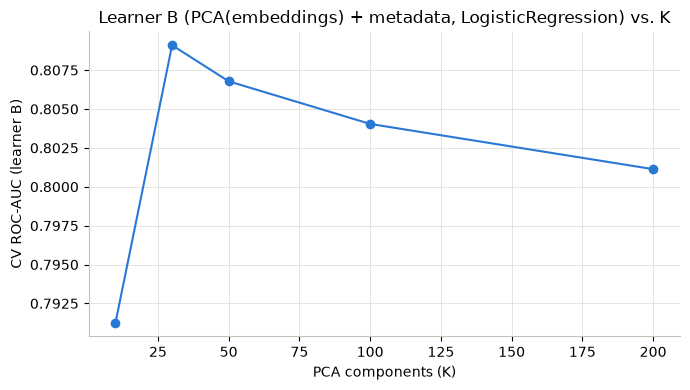

Best K by raw CV AUC: 30 (AUC=0.8091)
Chosen K (simplest within 0.005 of best): 30


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_results_df["K"], k_results_df["cv_roc_auc"], marker="o", color="#2a78d6")
ax.set_xlabel("PCA components (K)")
ax.set_ylabel("CV ROC-AUC (learner B)")
ax.set_title("Learner B (PCA(embeddings) + metadata, LogisticRegression) vs. K")
plt.tight_layout()
plt.show()

best_auc = k_results_df["cv_roc_auc"].max()
TOLERANCE = 0.005
candidates = k_results_df[k_results_df["cv_roc_auc"] >= best_auc - TOLERANCE]
CHOSEN_K = int(candidates["K"].min())
print(f"Best K by raw CV AUC: {int(k_results_df.loc[k_results_df['cv_roc_auc'].idxmax(), 'K'])} (AUC={best_auc:.4f})")
print(f"Chosen K (simplest within {TOLERANCE} of best): {CHOSEN_K}")

In [15]:
oof_A = np.full(len(dev_pool), np.nan)
oof_B = np.full(len(dev_pool), np.nan)

for train_idx, test_idx in FOLDS:
    clf_A = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    clf_A.fit(X_dev_A[train_idx], y_dev[train_idx])
    oof_A[test_idx] = clf_A.predict_proba(X_dev_A[test_idx])[:, list(clf_A.classes_).index(1)]

    pipe_B = build_learner_b(CHOSEN_K)
    pipe_B.fit(X_dev_A[train_idx], y_dev[train_idx])
    oof_B[test_idx] = pipe_B.predict_proba(X_dev_A[test_idx])[:, list(pipe_B.named_steps["clf"].classes_).index(1)]

auc_A = roc_auc_score(y_dev, oof_A)
auc_B = roc_auc_score(y_dev, oof_B)
auc_avg = roc_auc_score(y_dev, (oof_A + oof_B) / 2)

stack_X = np.column_stack([oof_A, oof_B])
meta_oof = np.full(len(dev_pool), np.nan)
for train_idx, test_idx in FOLDS:
    meta = LogisticRegression(class_weight="balanced", max_iter=1000)
    meta.fit(stack_X[train_idx], y_dev[train_idx])
    meta_oof[test_idx] = meta.predict_proba(stack_X[test_idx])[:, list(meta.classes_).index(1)]
auc_stacked = roc_auc_score(y_dev, meta_oof)

print(f"Learner A (HistGradientBoosting, raw embeddings + metadata):  OOF ROC-AUC = {auc_A:.4f}")
print(f"Learner B (LogReg, PCA-{CHOSEN_K} + metadata):                        OOF ROC-AUC = {auc_B:.4f}")
print(f"Simple average of A+B:                                        OOF ROC-AUC = {auc_avg:.4f}")
print(f"Stacked (LogReg meta-learner on OOF A+B):                     OOF ROC-AUC = {auc_stacked:.4f}")

Learner A (HistGradientBoosting, raw embeddings + metadata):  OOF ROC-AUC = 0.8318
Learner B (LogReg, PCA-30 + metadata):                        OOF ROC-AUC = 0.8082
Simple average of A+B:                                        OOF ROC-AUC = 0.8342
Stacked (LogReg meta-learner on OOF A+B):                     OOF ROC-AUC = 0.8334


In [16]:
candidates = {"learner_A": auc_A, "learner_B": auc_B, "average": auc_avg, "stacked": auc_stacked}
best_name = max(candidates, key=candidates.get)
print(f"Best in-distribution approach: {best_name} ({candidates[best_name]:.4f})")
if candidates["stacked"] <= max(auc_A, auc_B) + 0.002:
    print("Stacking did not meaningfully beat the best single base learner on this dev pool.")
else:
    print("Stacking beat both single base learners.")

clf_A_full = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_dev_A, y_dev)
pipe_B_full = build_learner_b(CHOSEN_K).fit(X_dev_A, y_dev)
meta_full = LogisticRegression(class_weight="balanced", max_iter=1000).fit(stack_X, y_dev)

proba_A_h = clf_A_full.predict_proba(X_holdout_A)[:, list(clf_A_full.classes_).index(1)]
proba_B_h = pipe_B_full.predict_proba(X_holdout_A)[:, list(pipe_B_full.named_steps["clf"].classes_).index(1)]
proba_avg_h = (proba_A_h + proba_B_h) / 2
proba_stacked_h = meta_full.predict_proba(np.column_stack([proba_A_h, proba_B_h]))[:, list(meta_full.classes_).index(1)]

holdout_results = {
    "learner_A": roc_auc_score(y_holdout, proba_A_h),
    "learner_B": roc_auc_score(y_holdout, proba_B_h),
    "average": roc_auc_score(y_holdout, proba_avg_h),
    "stacked": roc_auc_score(y_holdout, proba_stacked_h),
    "plain_embedding_baseline (Section B)": plain_holdout_auc,
}
print("Held-out use case ROC-AUC, all approaches:")
for k, v in holdout_results.items():
    print(f"  {k:38s} {v:.4f}")

Best in-distribution approach: average (0.8342)
Stacking did not meaningfully beat the best single base learner on this dev pool.


Held-out use case ROC-AUC, all approaches:
  learner_A                              0.5569
  learner_B                              0.5563
  average                                0.5862
  stacked                                0.5857
  plain_embedding_baseline (Section B)   0.5303


## Wrap-up

In [17]:
summary = pd.DataFrame([
    {"stage": "naive CV (StratifiedKFold, shuffle=False, block-ordered data)", "in_distribution_auc": naive_result["roc_auc"], "holdout_auc": None},
    {"stage": "+ shuffle=True only (still no grouping/use_case-stratification)", "in_distribution_auc": shuffled_no_group["roc_auc"], "holdout_auc": None},
    {"stage": "grouped+stratified CV (embeddings only)", "in_distribution_auc": grouped_result["roc_auc"], "holdout_auc": plain_holdout_auc},
    {"stage": "shuffled-label sanity check", "in_distribution_auc": shuffled_result["roc_auc"], "holdout_auc": None},
    {"stage": f"learner A (HGB, raw emb+meta)", "in_distribution_auc": auc_A, "holdout_auc": holdout_results["learner_A"]},
    {"stage": f"learner B (LogReg, PCA-{CHOSEN_K}+meta)", "in_distribution_auc": auc_B, "holdout_auc": holdout_results["learner_B"]},
    {"stage": "average(A, B)", "in_distribution_auc": auc_avg, "holdout_auc": holdout_results["average"]},
    {"stage": "stacked (meta LogReg)", "in_distribution_auc": auc_stacked, "holdout_auc": holdout_results["stacked"]},
])
summary

,stage,in_distribution_auc,holdout_auc
0,"naive CV (StratifiedKFold, shuffle=False, bloc...",0.601093,NaN
1,+ shuffle=True only (still no grouping/use_cas...,0.815134,NaN
2,grouped+stratified CV (embeddings only),0.801752,0.530270
3,shuffled-label sanity check,0.526160,NaN
4,"learner A (HGB, raw emb+meta)",0.831751,0.556878
5,"learner B (LogReg, PCA-30+meta)",0.808222,0.556343
6,"average(A, B)",0.834246,0.586225
7,stacked (meta LogReg),0.833367,0.585690
